# Lecture 4 — When Once Is Not Enough

**Module 3: Pythonic LLM Engineering**

Last week you made the API refuse you, read the headers, and waited. Today you build something that does not need you to sit there waiting.

Four labs. By the end you will have a client worth importing into everything else you build in this module.

Run from your project folder: `uv run jupyter lab`

---
## Setup

In [1]:
import os, time, random, statistics
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

client = OpenAI(
    api_key=os.environ["GROQ_API_KEY"],
    base_url="https://api.groq.com/openai/v1",
)

MODEL = "openai/gpt-oss-20b"

# Rates for a hosted provider, so cost stays visible even though Groq is free.
IN_RATE, OUT_RATE = 0.20, 1.20

def cost(usage):
    return (usage.prompt_tokens * IN_RATE
            + usage.completion_tokens * OUT_RATE) / 1_000_000

print("ready:", MODEL)

ready: openai/gpt-oss-20b


### Remind yourself of your limits

You found these last week. Check them again — they are the numbers Lab 4 is tuned against.

In [21]:
raw = client.chat.completions.with_raw_response.create(
    model=MODEL,
    messages=[{"role": "user", "content": "Say OK."}],
    max_completion_tokens=5,
)

for k in sorted(raw.headers):
    if "ratelimit" in k.lower():
        print(f"{k:<34}{raw.headers[k]}")

x-ratelimit-limit-requests        1000
x-ratelimit-limit-tokens          8000
x-ratelimit-remaining-requests    810
x-ratelimit-remaining-tokens      7921
x-ratelimit-reset-requests        4h33m36s
x-ratelimit-reset-tokens          592ms


---
# Lab 1 — Retries that know when to stop

*Twenty minutes.*

### 1a. Decide what is worth retrying

Before writing any retry logic, write down the rule. A retry is worth attempting when the **request was fine and the circumstances were not**.

In [3]:
# Status codes that mean 'try again later'
RETRYABLE_STATUS = {408, 409, 429, 500, 502, 503, 504}

# Exception names that mean the request never completed
RETRYABLE_NAMES = {"APITimeoutError", "APIConnectionError",
                   "InternalServerError", "RateLimitError"}


def is_retryable(err):
    status = getattr(err, "status_code", None)
    if status is not None:
        return status in RETRYABLE_STATUS
    return type(err).__name__ in RETRYABLE_NAMES


print("rule defined")

rule defined


**Before moving on**, answer in one line: why is retrying a 401 worse than simply failing?

Because 401 means the attempt was unauthorized, the server might blacklist you for suspicious activity.

### 1b. Backoff with jitter, and retry-after when offered

Three ideas in one function. Read it before you run it.

1. Wait longer after each failure — `base * 2 ** attempt`
2. Randomise the wait, so thirty clients do not collide
3. If the provider told you how long to wait, **use that instead**

In [4]:
def wait_time(err, attempt, base=1.0, cap=30.0):
    """How long to sleep before the next attempt."""
    # 1. The provider knows better than we do.
    response = getattr(err, "response", None)
    header = getattr(response, "headers", {}) or {}
    told = header.get("retry-after")
    if told:
        try:
            return float(told)
        except ValueError:
            pass

    # 2. Otherwise: exponential, capped, with full jitter.
    ceiling = min(cap, base * (2 ** attempt))
    return random.uniform(0, ceiling)


# What does that look like over five attempts?
for a in range(5):
    ceiling = min(30.0, 1.0 * (2 ** a))
    print(f"attempt {a}: ceiling {ceiling:>5.1f}s, sample waits {[round(random.uniform(0, ceiling), 2) for _ in range(3)]}")

attempt 0: ceiling   1.0s, sample waits [0.29, 0.92, 0.06]
attempt 1: ceiling   2.0s, sample waits [0.62, 0.55, 1.22]
attempt 2: ceiling   4.0s, sample waits [1.16, 3.01, 1.58]
attempt 3: ceiling   8.0s, sample waits [6.13, 7.97, 2.32]
attempt 4: ceiling  16.0s, sample waits [9.63, 12.45, 8.73]


### 1c. Put it together

`robust_call` is the function you will import for the rest of the module. Write it once, carefully.

In [5]:
class CallFailed(Exception):
    pass


def robust_call(messages, model=None, max_attempts=5, base=1.0,
                verbose=True, **kwargs):
    """A call that retries what is worth retrying and refuses what is not."""
    attempts = []

    for attempt in range(max_attempts):
        try:
            r = client.chat.completions.create(
                model=model or MODEL, messages=messages, **kwargs)
            if attempt and verbose:
                print(f"  succeeded on attempt {attempt + 1}")
            robust_call.last_attempts = attempt + 1
            return r

        except Exception as e:
            status = getattr(e, "status_code", "n/a")
            attempts.append((type(e).__name__, status))

            if not is_retryable(e):
                if verbose:
                    print(f"  giving up immediately: {type(e).__name__} {status}")
                raise CallFailed(f"not retryable: {type(e).__name__} {status}") from e

            if attempt == max_attempts - 1:
                raise CallFailed(f"failed after {max_attempts} attempts") from e

            delay = wait_time(e, attempt, base=base)
            if verbose:
                print(f"  attempt {attempt + 1} failed ({status}), sleeping {delay:.2f}s")
            time.sleep(delay)


robust_call.last_attempts = 0
print("robust_call ready")

robust_call ready


### 1d. Prove it recovers

In [6]:
from concurrent.futures import ThreadPoolExecutor
from collections import Counter

def burst_one(_):
    try:
        robust_call([{"role": "user", "content": "Say OK."}],
                    max_completion_tokens=5, max_attempts=8, verbose=False)
        return "ok"
    except CallFailed as e:
        return f"gave up: {e}"

start = time.perf_counter()
with ThreadPoolExecutor(max_workers=20) as pool:
    results = list(pool.map(burst_one, range(60)))
elapsed = time.perf_counter() - start

print(f"60 requests, 20 in flight, {elapsed:.1f}s")
for k, v in Counter(results).most_common():
    print(f"  {k[:60]:<62}{v}")

60 requests, 20 in flight, 53.9s
  ok                                                            60


Last week that burst produced a wall of 429s and nothing else. Compare.

**Questions.**

1. It took longer than the failing version did. Is that a problem?
2. If any gave up, try raising `max_attempts`. Sixty requests against a thirty-a-minute limit needs roughly two minutes of patience however cleverly you back off — retries buy you reliability, not throughput.

1. It is not necessarily a problem, however it would be wise to inform the user of the wait and the reason.
2. This was not a question?

### 1e. Prove it knows when to give up

A retry loop that retries everything is worse than no retry loop at all. Point it at something that will never work and check that it fails **immediately**.

In [7]:
bad_client = OpenAI(
    api_key="gsk_definitely_not_a_real_key",
    base_url="https://api.groq.com/openai/v1",
)

real_client = client
client = bad_client        # temporarily point robust_call at the broken key

start = time.perf_counter()
try:
    robust_call([{"role": "user", "content": "hi"}])
except CallFailed as e:
    print("failed as expected:", e)
finally:
    client = real_client   # put it back

print(f"took {time.perf_counter() - start:.2f}s")
print("If that took more than a second, your rule is wrong.")

  giving up immediately: AuthenticationError 401
failed as expected: not retryable: AuthenticationError 401
took 0.07s
If that took more than a second, your rule is wrong.


**Questions.**

1. How long did the bad key take to fail? How long would it have taken with five retries and backoff?
2. How many retries did the burst in 1d need in total?
3. Look at your `wait_time`. When did it use `retry-after`, and when did it fall back to jitter?

1. It took 0.07s. With 5 retries it would have taken 2^5 = 32 seconds from the wait, without jitter.
2. 60 .
3. now it did retry-after, before it fell back to jitter.

---
# Lab 2 — The failure that tells you nothing

*Fifteen minutes.*

### 2a. Cause a timeout

In [8]:
import httpx

impatient = OpenAI(
    api_key=os.environ["GROQ_API_KEY"],
    base_url="https://api.groq.com/openai/v1",
    timeout=httpx.Timeout(0.4),   # far too short on purpose
)

try:
    impatient.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": "Write a long essay about triage."}],
    )
    print("no timeout - try lowering it further")
except Exception as e:
    print("exception :", type(e).__name__)
    print("status    :", getattr(e, "status_code", "none"))
    print("retryable?:", is_retryable(e))

exception : APITimeoutError
status    : none
retryable?: True


### 2b. The uncomfortable question

You got a timeout. Now answer honestly: **did the model generate an answer?**

You cannot tell from your side. The request may have arrived, been processed, and been billed, with only the reply lost on the way back. Or it may never have arrived.

For text generation this does not matter much — you pay twice and keep one answer. Design an experiment that would tell you whether the work happened.

I went into the dashboard view of Groq and checked my usage logs. I could see that the model generated a respones with code 200, then it shows 2 499 errors in the log. I had to look it up but 499 means client closed connection, so that is exactly what should happen.

*(Hint: you cannot, from the client. What would you need the provider to give you?)*

### 2c. A time budget, not just an attempt count

Five attempts with backoff can take over a minute. If a user is waiting, that is far too long. Real clients bound the **total** time, not just the number of tries.

In [10]:
def robust_call_v2(messages, model=None, max_attempts=5, base=1.0,
                   deadline=20.0, verbose=True, **kwargs):
    """As before, but gives up when the total time budget runs out."""
    started = time.perf_counter()

    for attempt in range(max_attempts):
        try:
            return client.chat.completions.create(
                model=model or MODEL, messages=messages, **kwargs)

        except Exception as e:
            if not is_retryable(e):
                raise CallFailed(f"not retryable: {type(e).__name__}") from e

            elapsed = time.perf_counter() - started
            delay = wait_time(e, attempt, base=base)

            if elapsed + delay > deadline:
                raise CallFailed(
                    f"deadline of {deadline}s would be exceeded "
                    f"(used {elapsed:.1f}s, next wait {delay:.1f}s)") from e

            if verbose:
                print(f"  attempt {attempt + 1} failed, sleeping {delay:.2f}s "
                      f"({elapsed:.1f}s of {deadline}s used)")
            time.sleep(delay)

    raise CallFailed(f"failed after {max_attempts} attempts")


# Sanity check: it still works when nothing is wrong.
r = robust_call_v2([{"role": "user", "content": "Say OK."}], max_completion_tokens=5)
print("normal call still fine:", r.choices[0].message.content)

normal call still fine: 


**Write two lines in your notebook.**

For *your* capstone idea: is a retried call safe? What would have to be true for it not to be? Be specific about what your system does after the model replies.

While we do not yet have a solid idea for a capstone project proposal, retried calls seem safe to me as long as it is certain to not mess with the output of your request. It should also be logged properly, so afterwards the results can be examined for possible flaws in the results.

---
# Lab 3 — Streaming

*Fifteen minutes.*

### 3a. Watch it arrive

In [12]:
prompt = [{"role": "user",
           "content": "Explain how hospital triage works, in about 200 words."}]

start = time.perf_counter()
first_token_at = None

stream = client.chat.completions.create(
    model=MODEL, messages=prompt, stream=True,
    stream_options={"include_usage": True},
)

for chunk in stream:
    if chunk.choices and chunk.choices[0].delta.content:
        if first_token_at is None:
            first_token_at = time.perf_counter() - start
        print(chunk.choices[0].delta.content, end="", flush=True)

total = time.perf_counter() - start
print(f"\n\n--- first token after {first_token_at:.2f}s, finished after {total:.2f}s ---")

**Hospital Triage: The Quick‑Sort of Patient Care**

When a large influx of patients arrives—whether at an emergency department, during a mass casualty event, or on a busy day—triage is the first line of organization. A triage nurse or trained medical officer quickly assesses each patient’s condition using a standardized system (most commonly the **Emergency Severity Index (ESI)**, **Manchester Triage System (MTS)**, or the **American College of Surgeons’ Triage Protocol**). The goal is to determine urgency, predict resource needs, and prioritize treatment without delaying care for anyone.

1. **Rapid assessment** – The triage practitioner asks a brief set of questions, checks vital signs, and observes symptoms. They look for life‑threatening or time‑critical conditions: airway obstruction, severe bleeding, cardiac arrest, or severe pain.

2. **Classification** – Patients are assigned a **triage level**. For example, ESI ranges from 1 (most critical, requires immediate resuscitation) t

### 3b. Compare with blocking

Same prompt, no streaming. Time to first token *is* the total time, because nothing appears until everything does.

In [13]:
start = time.perf_counter()
r = client.chat.completions.create(model=MODEL, messages=prompt)
blocking_total = time.perf_counter() - start

print(f"{'':<12}{'first token':>14}{'total':>10}")
print(f"{'streaming':<12}{first_token_at:>13.2f}s{total:>9.2f}s")
print(f"{'blocking':<12}{blocking_total:>13.2f}s{blocking_total:>9.2f}s")
print()
print(f"streaming showed something {blocking_total / first_token_at:.0f}x sooner")

               first token     total
streaming            0.25s     0.75s
blocking             0.64s     0.64s

streaming showed something 3x sooner


**Question.** Which of those four numbers would a user notice?

The user will notice the first token appearing. When a user asks a question and the output is streamed, the user can already start reading the moment the first tokens appear.

### 3c. Recover what streaming hides

You have spent two weeks checking `finish_reason` and logging `usage`. Streaming gives you neither with the text. Get them back.

In [14]:
stream = client.chat.completions.create(
    model=MODEL, messages=prompt, stream=True,
    stream_options={"include_usage": True},
)

text_parts, finish_reason, usage = [], None, None

for chunk in stream:
    if chunk.choices:
        delta = chunk.choices[0].delta.content
        if delta:
            text_parts.append(delta)
        if chunk.choices[0].finish_reason:
            finish_reason = chunk.choices[0].finish_reason
    # usage arrives on the final chunk, and only if you asked for it
    if getattr(chunk, "usage", None):
        usage = chunk.usage

answer = "".join(text_parts)
print(f"characters    : {len(answer)}")
print(f"finish_reason : {finish_reason}")
print(f"usage         : {usage}")
if usage:
    print(f"cost          : ${cost(usage):.6f}")

characters    : 1448
finish_reason : stop
usage         : CompletionUsage(completion_tokens=365, prompt_tokens=84, total_tokens=449, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=None, reasoning_tokens=39, rejected_prediction_tokens=None, text_tokens=None), prompt_tokens_details=None, queue_time=0.147241729, prompt_time=0.004817179, completion_time=0.487760471, total_time=0.49257765)
cost          : $0.000455


### 3d. Now break it

Remove the `stream_options` line and run the same loop. Watch what your cost logging reports.

In [15]:
stream = client.chat.completions.create(
    model=MODEL, messages=prompt, stream=True,
    # stream_options deliberately omitted
)

usage = None
for chunk in stream:
    if getattr(chunk, "usage", None):
        usage = chunk.usage

print("usage:", usage)
print("cost :", f"${cost(usage):.6f}" if usage else "$0.000000  <- a lie")

usage: CompletionUsage(completion_tokens=385, prompt_tokens=84, total_tokens=469, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=None, reasoning_tokens=28, rejected_prediction_tokens=None, text_tokens=None), prompt_tokens_details=None, queue_time=0.148455415, prompt_time=0.004689645, completion_time=0.475774914, total_time=0.480464559)
cost : $0.000479


**Questions.**

1. What did your cost tracking report when `stream_options` was missing?
2. Is reporting zero betterr or worse than reporting nothing at all? Why?
3. Do the token counts from the stream match a non-streamed call for the same prompt?

1. Everything except the characters and the stop reason
2. Reporting 0 is worse, since that could give the impression that the 0 is an actual value instead of just leaving the information unknown.
3. No the one without streaming was a bit more expensive.

---
# Lab 4 — How many at once?

*Twenty minutes.*

More workers is faster, until it is slower. Find the turning point for **your** account, with **your** limits.

In [16]:
PROMPTS = [
    f"In one sentence, name a common cause of {ailment}."
    for ailment in [
        "chest pain", "headache", "fever", "back pain", "dizziness",
        "shortness of breath", "nausea", "fatigue", "joint pain", "cough",
        "sore throat", "abdominal pain", "rash", "blurred vision", "insomnia",
        "palpitations", "swelling", "numbness", "weight loss", "earache",
    ]
]

print(len(PROMPTS), "prompts ready")

20 prompts ready


### 4a. Sequential — the baseline

In [20]:
start = time.perf_counter()
done = 0
for p in PROMPTS:
    try:
        robust_call([{"role": "user", "content": p}],
                    max_completion_tokens=40, verbose=False)
        done += 1
    except CallFailed as e:
        print(f"  one prompt gave up: {e}")
sequential = time.perf_counter() - start

print(f"sequential: {sequential:.1f}s for {done}/{len(PROMPTS)} prompts "
      f"({sequential / len(PROMPTS):.2f}s each)")

sequential: 5.5s for 20/20 prompts (0.27s each)


### 4b. Sweep the worker count

This is the measurement. Each setting runs all twenty prompts and counts how many retries were needed along the way.

In [18]:
retry_count = 0
fail_count = 0
MAX_ATTEMPTS = 8

def counted_call(prompt):
    """Never raises. A failure is a measurement too."""
    global retry_count, fail_count
    for attempt in range(MAX_ATTEMPTS):
        try:
            return client.chat.completions.create(
                model=MODEL, messages=[{"role": "user", "content": prompt}],
                max_completion_tokens=40)
        except Exception as e:
            if not is_retryable(e):
                fail_count += 1
                return None
            if attempt == MAX_ATTEMPTS - 1:
                fail_count += 1
                return None
            retry_count += 1
            time.sleep(wait_time(e, attempt))


measurements = []
for workers in (1, 4, 8, 16, 32):
    retry_count = fail_count = 0
    start = time.perf_counter()
    with ThreadPoolExecutor(max_workers=workers) as pool:
        list(pool.map(counted_call, PROMPTS))
    took = time.perf_counter() - start
    measurements.append((workers, took, retry_count, fail_count))
    note = f"   {fail_count} gave up" if fail_count else ""
    print(f"{workers:>3} workers: {took:>6.1f}s   {retry_count:>3} retries{note}")
    time.sleep(3)   # let the window recover between runs

  1 workers:    6.6s     0 retries
  4 workers:   26.1s    10 retries
  8 workers:   35.5s    28 retries
 16 workers:   29.8s    30 retries
 32 workers:   31.1s    47 retries


### 4c. Plot it

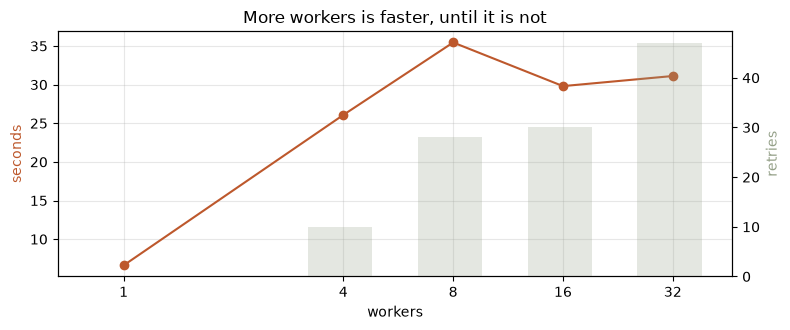

In [19]:
import matplotlib.pyplot as plt

w = [m[0] for m in measurements]
t = [m[1] for m in measurements]
rt = [m[2] for m in measurements]
fl = [m[3] for m in measurements]

fig, ax1 = plt.subplots(figsize=(8, 3.4))
ax1.plot(w, t, marker="o", color="#BD582C", label="seconds")
ax1.set_xlabel("workers"); ax1.set_ylabel("seconds", color="#BD582C")
ax1.set_xscale("log", base=2); ax1.set_xticks(w)
ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.bar(w, rt, alpha=0.25, color="#94A088", width=[x * 0.4 for x in w])
ax2.set_ylabel("retries", color="#94A088")

if any(fl):
    print("note: some prompts gave up entirely at", 
          [w[i] for i, f in enumerate(fl) if f], "workers")
plt.title("More workers is faster, until it is not")
plt.tight_layout(); plt.show()

**Questions.**

1. At what worker count did the improvement stop?
2. At what point did it get *worse*? What does the retry bar do there?
3. Compare your best time with the sequential baseline. What speed-up did you get?
4. Your rate limit is a number you read at the top of this notebook. Does the turning point match it?
5. **What worker count would you actually ship, and why?** One sentence.

1. There wasn't a single improvement in this measurement. The performance dropped from 6.6s with 1 worker to 26.1 with 4.
2. Immediatly?
3. My best time was 6.6, which is faster than the baseline. However i ran the baseline again giving me 5.5s. It seems a bit random but overall no improvements.
4. The rate limit on the top of the page was 592ms. The turning point, let's say 4 workers, did not reach that. Something else seems wrong with these measurements. In theory you'd assume the turning point should have been around 8-16 workers.
5. I would not ship more tha one based on the results above, since it would add complications without any benefit.

---
## Before you leave

- [x] Move `is_retryable`, `wait_time` and `robust_call` into a file called `llm_client.py` and import it here to check it still works
- [x] Commit it. You will import this every week from now on
- [x] Write down your chosen worker count and the numbers that justify it
- [x] Confirm `.env` is still not in the commit

**Next week:** the prompt itself. Templated, versioned and reviewed rather than buried in an f-string — and the first serious look at prompt injection.

---

### Your notes

> _worker count I would ship, and why:_
>
> _the thing that surprised me today:_